전이학습 Xception으로 이거 미리 해보기!! 내일 오전 진행 예정

seg_test : 폴더명이 label 값이야. train과 동일. 사실상 valid 데이터

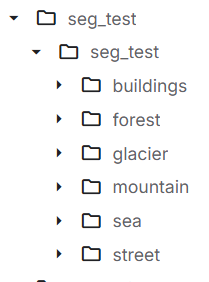

seg_pred : label이 없어. 사실상 test 데이터

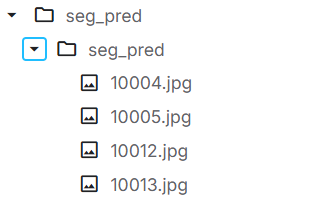

In [ ]:
# import kagglehub

# Download latest version
# 경로를..바꾸렴^^
# path = kagglehub.dataset_download("puneet6060/intel-image-classification")

# print("Path to dataset files:", path)

c:\Users\user\miniconda3\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 346M/346M [00:11<00:00, 30.9MB/s] 

Extracting files...


Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


### 탐색적 데이터 분석(EDA)

In [9]:
# /kaggle/input/intel-image-classification
import os

Is_Kaggle = False

if Is_Kaggle == True:
    datapath = '/kaggle/input/intel-image-classification'
else:
    datapath = 'Intel_Image'

fileNames = os.listdir(datapath)
fileNames

['seg_pred', 'seg_test', 'seg_train']

### Train 데이터셋의 폴더를 확인

지금처럼 폴더명이 target인 경우

csv를 만들어서 파일명 - 폴더명 이렇게 연결지어서 만드는 경우도 있고

그대로 폴더명을 label로 사용하는 경우도 있어

In [10]:
trainPath = os.path.join(datapath, 'seg_train', 'seg_train')
labels = os.listdir(trainPath)

# 'buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'
labels

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [11]:
# trainPath의 폴더별 이미지 파일의 갯수를 확인

print(f"{'Folder Name':<20} | {'Image Count':<10}")
print("-" * 35)
total_images = 0
for folder in sorted(os.listdir(trainPath)):
    folder_path = os.path.join(trainPath, folder)
    
    # 디렉토리인 경우에만 파일 개수 확인
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"{folder:<20} | {count:<10,}")
        total_images += count
print("-" * 35)
print(f"{'Total':<20} | {total_images:<10,}")


Folder Name          | Image Count
-----------------------------------
buildings            | 2,191     
forest               | 2,271     
glacier              | 2,404     
mountain             | 2,512     
sea                  | 2,274     
street               | 2,382     
-----------------------------------
Total                | 14,034    


C:\Users\user\AppData\Local\Temp\ipykernel_956\3628933849.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=folders, y=counts, palette=colors, edgecolor='black')


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'buildings'),
  Text(1, 0, 'forest'),
  Text(2, 0, 'glacier'),
  Text(3, 0, 'mountain'),
  Text(4, 0, 'sea'),
  Text(5, 0, 'street')])

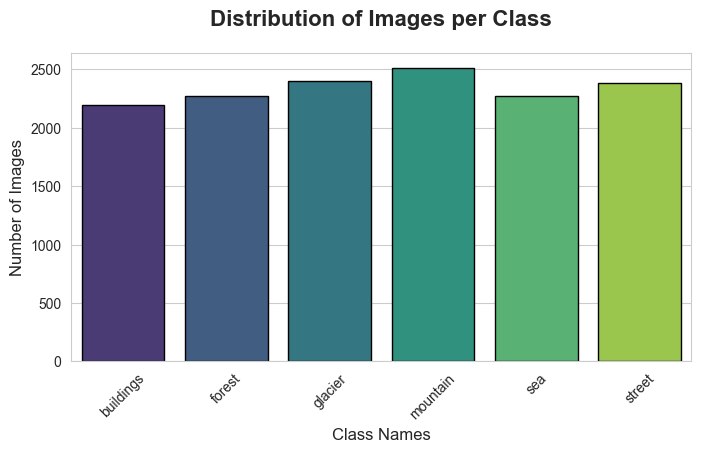

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 수집
# trainPath
folders = []
counts = []

for folder in sorted(os.listdir(trainPath)):
    folder_path = os.path.join(trainPath, folder)
    if os.path.isdir(folder_path):
        folders.append(folder)
        counts.append(len(os.listdir(folder_path)))

# 2. 시각화 설정
plt.figure(figsize=(8, 4))
sns.set_style("whitegrid")

# 막대 그래프 그리기 (seaborn 사용 시 더욱 미려한 결과가 나옵니다)
colors = sns.color_palette('viridis', len(folders))
barplot = sns.barplot(x=folders, y=counts, palette=colors, edgecolor='black')

# 그래프 장식
plt.title('Distribution of Images per Class', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Class Names', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45) # x축 회전 45도
